In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("./data/diabetes-data.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<Axes: ylabel='SkinThickness'>

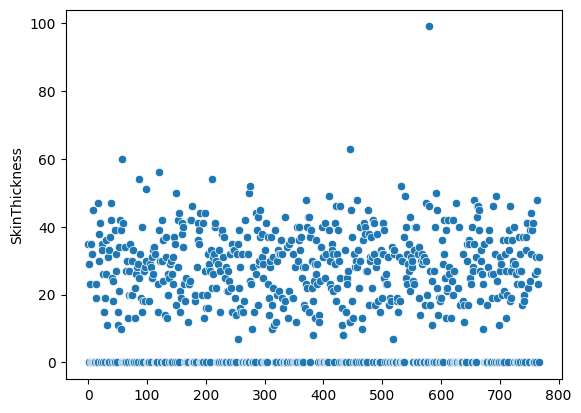

In [77]:
sns.scatterplot(df["SkinThickness"])

In [78]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='SkinThickness'>

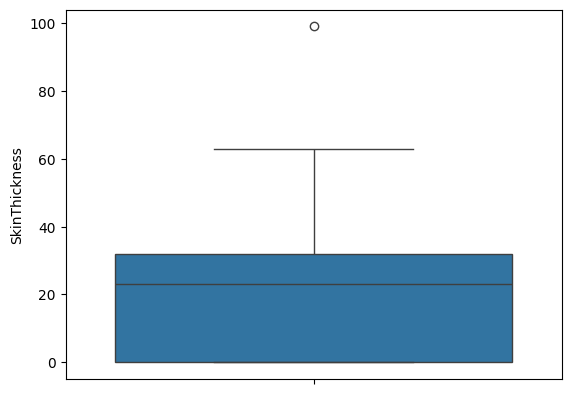

In [79]:
sns.boxplot(df["SkinThickness"])

In [80]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [81]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [83]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [84]:
df1 = df.copy(deep=True)
df1[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] = df1[[
    'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']].replace(0, np.nan)
print(df1.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


<Axes: xlabel='SkinThickness', ylabel='Count'>

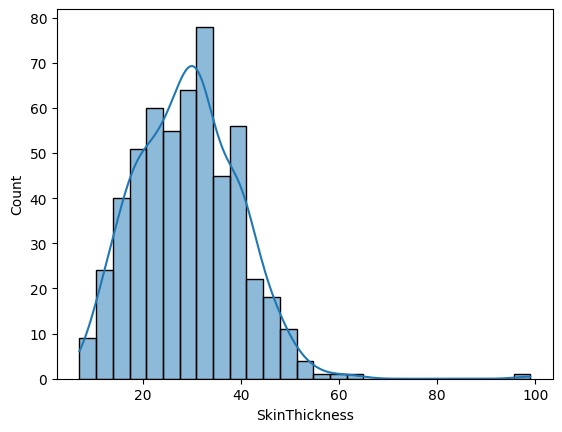

In [85]:
sns.histplot(df1["SkinThickness"], kde=True)

<Axes: xlabel='Glucose', ylabel='Count'>

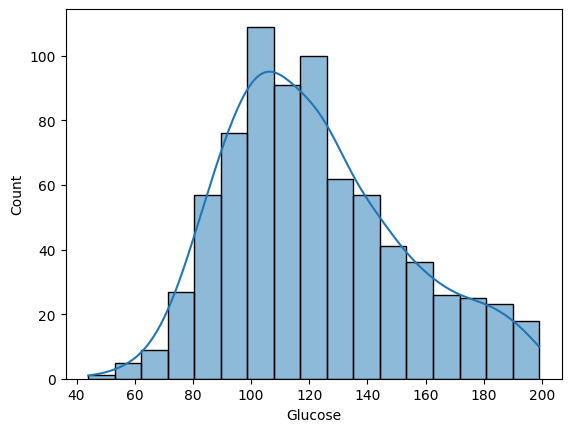

In [86]:
sns.histplot(df1["Glucose"], kde=True)

In [ ]:
df1['Glucose'].fillna(df1['Glucose'].mean(), inplace=True)
df1['BloodPressure'].fillna(df1['BloodPressure'].mean(), inplace=True)
df1['SkinThickness'].fillna(df1['SkinThickness'].median(), inplace=True)
df1['Insulin'].fillna(df1['Insulin'].median(), inplace=True)
df1['BMI'].fillna(df1['BMI'].median(), inplace=True)

In [88]:
df1['Glucose'] = pd.cut(
    df1['Glucose'],
    bins=[0, 70, 99, 125, float("inf")],
    labels=['Low-glucose', "Normal", "Pre-diabetes", "Diabetes"]
)

<Axes: ylabel='Glucose'>

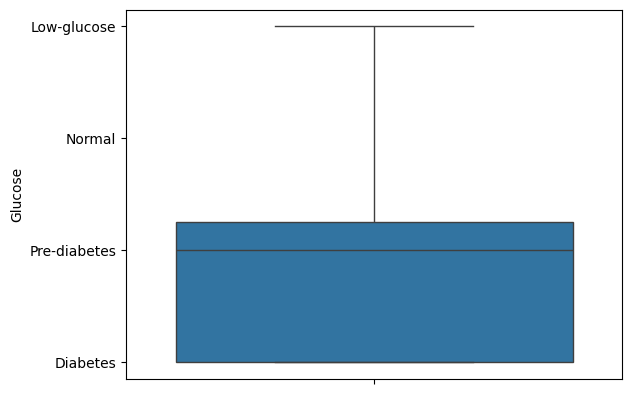

In [89]:
sns.boxplot(df1["Glucose"])

<Axes: xlabel='BloodPressure', ylabel='Count'>

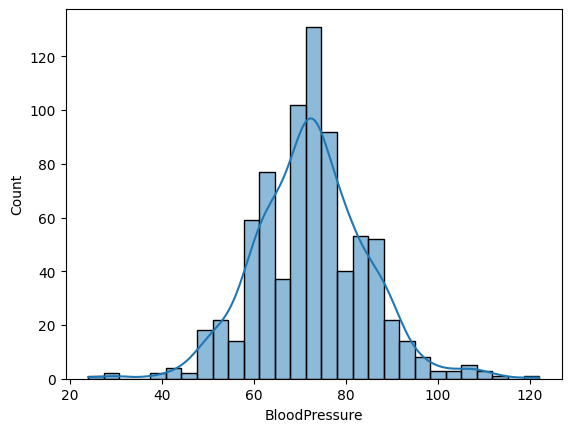

In [90]:
sns.histplot(df1["BloodPressure"], kde=True)

In [91]:
df1['DiabetesPedigreeFunction'] = pd.cut(
    df1['DiabetesPedigreeFunction'],
    bins=[0, .3, .8,   float("inf")],
    labels=['Low', "Medium", "High"]
)

In [92]:
df1["DiabetesPedigreeFunction"] = df1["DiabetesPedigreeFunction"].replace(
    "LowD", "Low")

In [93]:
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,Diabetes,72.0,35.0,125.0,33.6,Medium,50,1
1,1,Normal,66.0,29.0,125.0,26.6,Medium,31,0
2,8,Diabetes,64.0,29.0,125.0,23.3,Medium,32,1
3,1,Normal,66.0,23.0,94.0,28.1,Low,21,0
4,0,Diabetes,40.0,35.0,168.0,43.1,High,33,1
...,...,...,...,...,...,...,...,...,...
763,10,Pre-diabetes,76.0,48.0,180.0,32.9,Low,63,0
764,2,Pre-diabetes,70.0,27.0,125.0,36.8,Medium,27,0
765,5,Pre-diabetes,72.0,23.0,112.0,26.2,Low,30,0
766,1,Diabetes,60.0,29.0,125.0,30.1,Medium,47,1


In [94]:
df1['Insulin'] = pd.cut(
    df1['Insulin'],
    bins=[0, 50, 150, 300,  float("inf")],
    labels=['Low', "Normal", "High", "Very High"]
)

In [95]:
df1['BloodPressure'] = pd.cut(
    df1['BloodPressure'],
    bins=[0, 40, 60, 80, 90, float("inf")],
    labels=['Very-Low', "Low", "Normal", "Elevated", "High"]
)

In [96]:
df1['BMI'] = pd.cut(
    df1['BMI'],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=['Underweight', "Normal", "Overweight", "Obese"]
)

In [97]:
df1['Age'] = pd.cut(
    df1['Age'],
    bins=[0, 25, 35, 50, 65, float("inf")],
    labels=["Very-Young", "Young", "Middle", "Senior", "Old"]
)

<Axes: xlabel='BMI', ylabel='Count'>

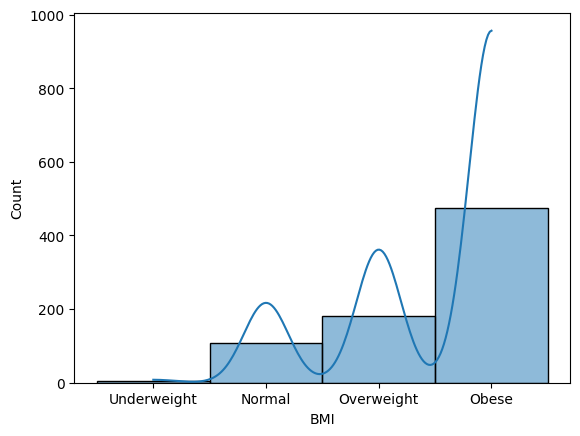

In [98]:
sns.histplot(df1["BMI"], kde=True)

In [99]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [100]:
df.groupby(['Outcome']).size()

Outcome
0    500
1    268
dtype: int64

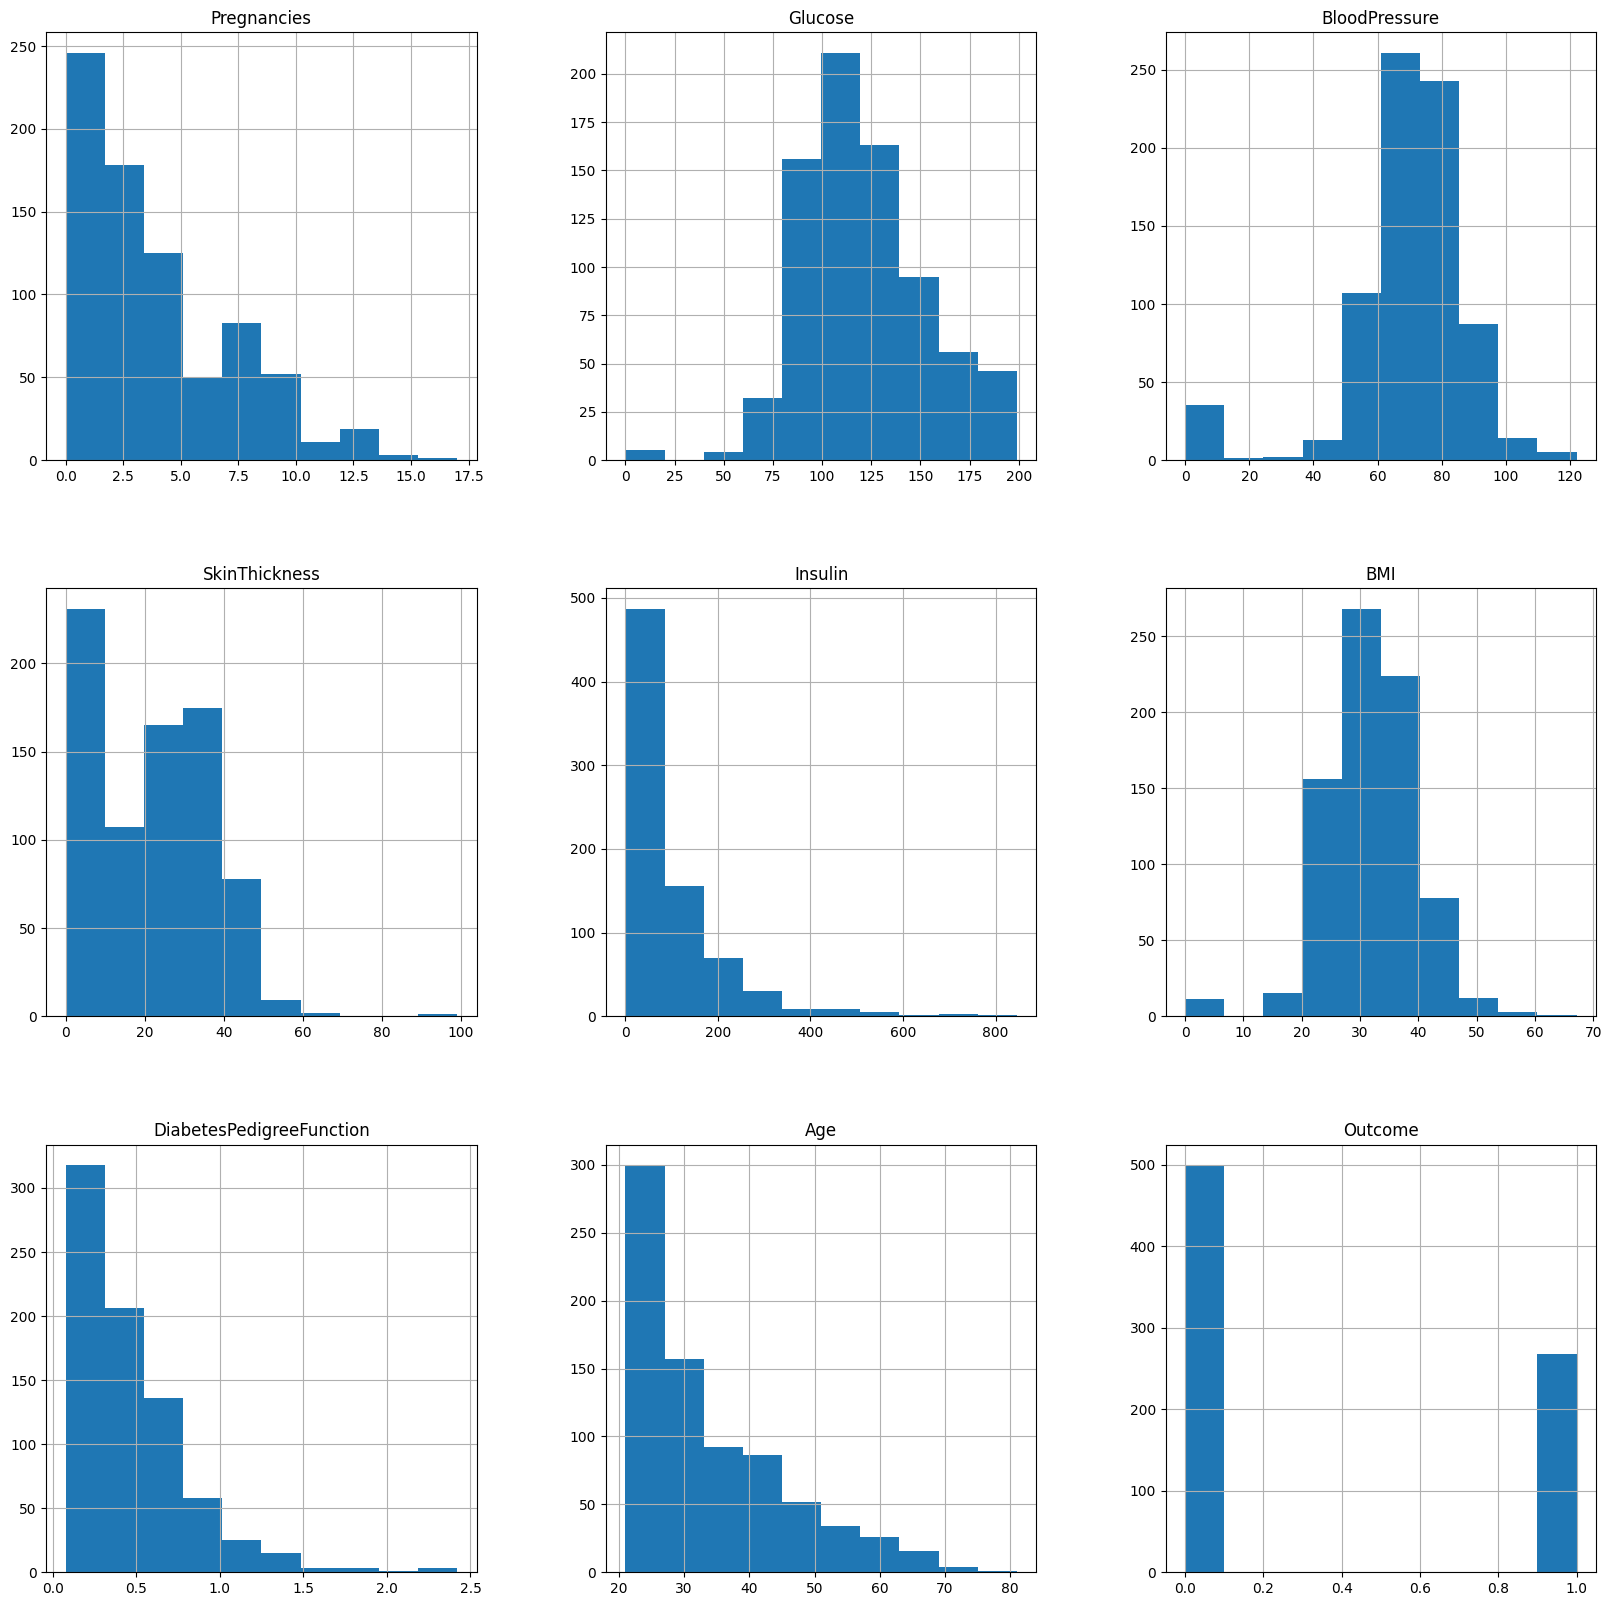

In [101]:
hplot = df.hist(figsize=(20, 20))

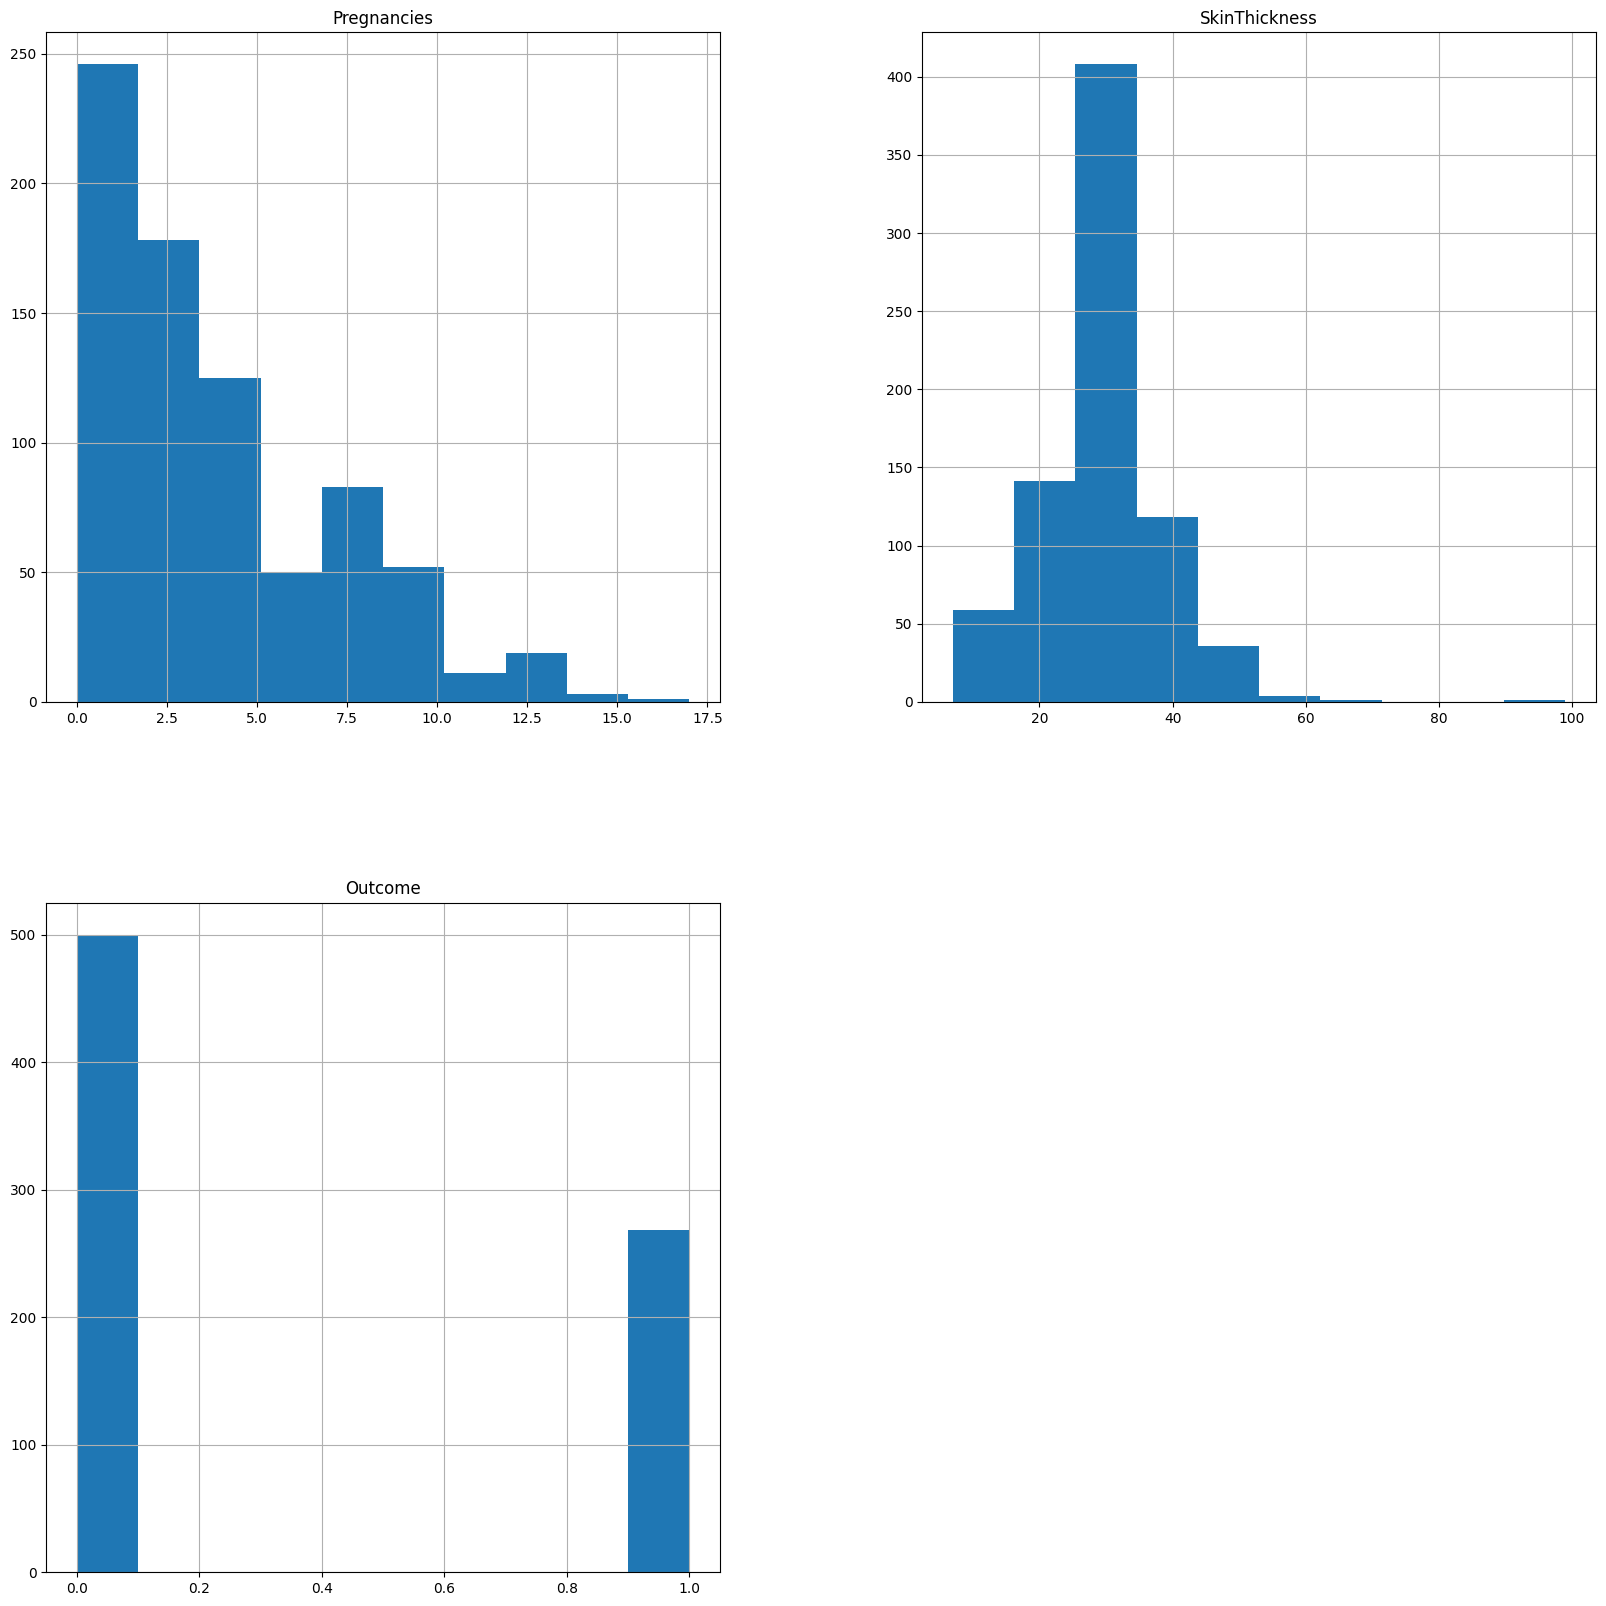

In [102]:
hplot = df1.hist(figsize=(20, 20))

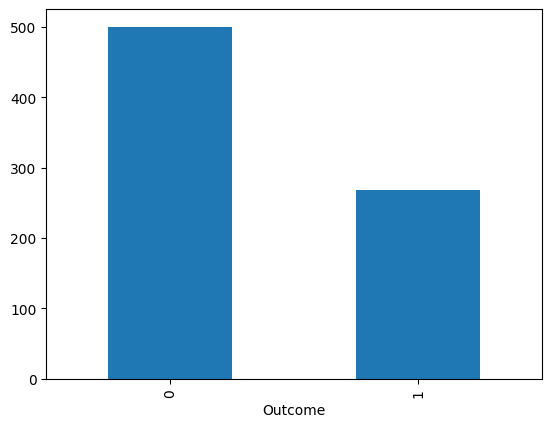

In [103]:
p = df.Outcome.value_counts().plot(kind="bar")

array([[<Axes: xlabel='Pregnancies', ylabel='Pregnancies'>,
        <Axes: xlabel='Glucose', ylabel='Pregnancies'>,
        <Axes: xlabel='BloodPressure', ylabel='Pregnancies'>,
        <Axes: xlabel='SkinThickness', ylabel='Pregnancies'>,
        <Axes: xlabel='Insulin', ylabel='Pregnancies'>,
        <Axes: xlabel='BMI', ylabel='Pregnancies'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Pregnancies'>,
        <Axes: xlabel='Age', ylabel='Pregnancies'>,
        <Axes: xlabel='Outcome', ylabel='Pregnancies'>],
       [<Axes: xlabel='Pregnancies', ylabel='Glucose'>,
        <Axes: xlabel='Glucose', ylabel='Glucose'>,
        <Axes: xlabel='BloodPressure', ylabel='Glucose'>,
        <Axes: xlabel='SkinThickness', ylabel='Glucose'>,
        <Axes: xlabel='Insulin', ylabel='Glucose'>,
        <Axes: xlabel='BMI', ylabel='Glucose'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Glucose'>,
        <Axes: xlabel='Age', ylabel='Glucose'>,
        <Axes: xlabel='Outcom

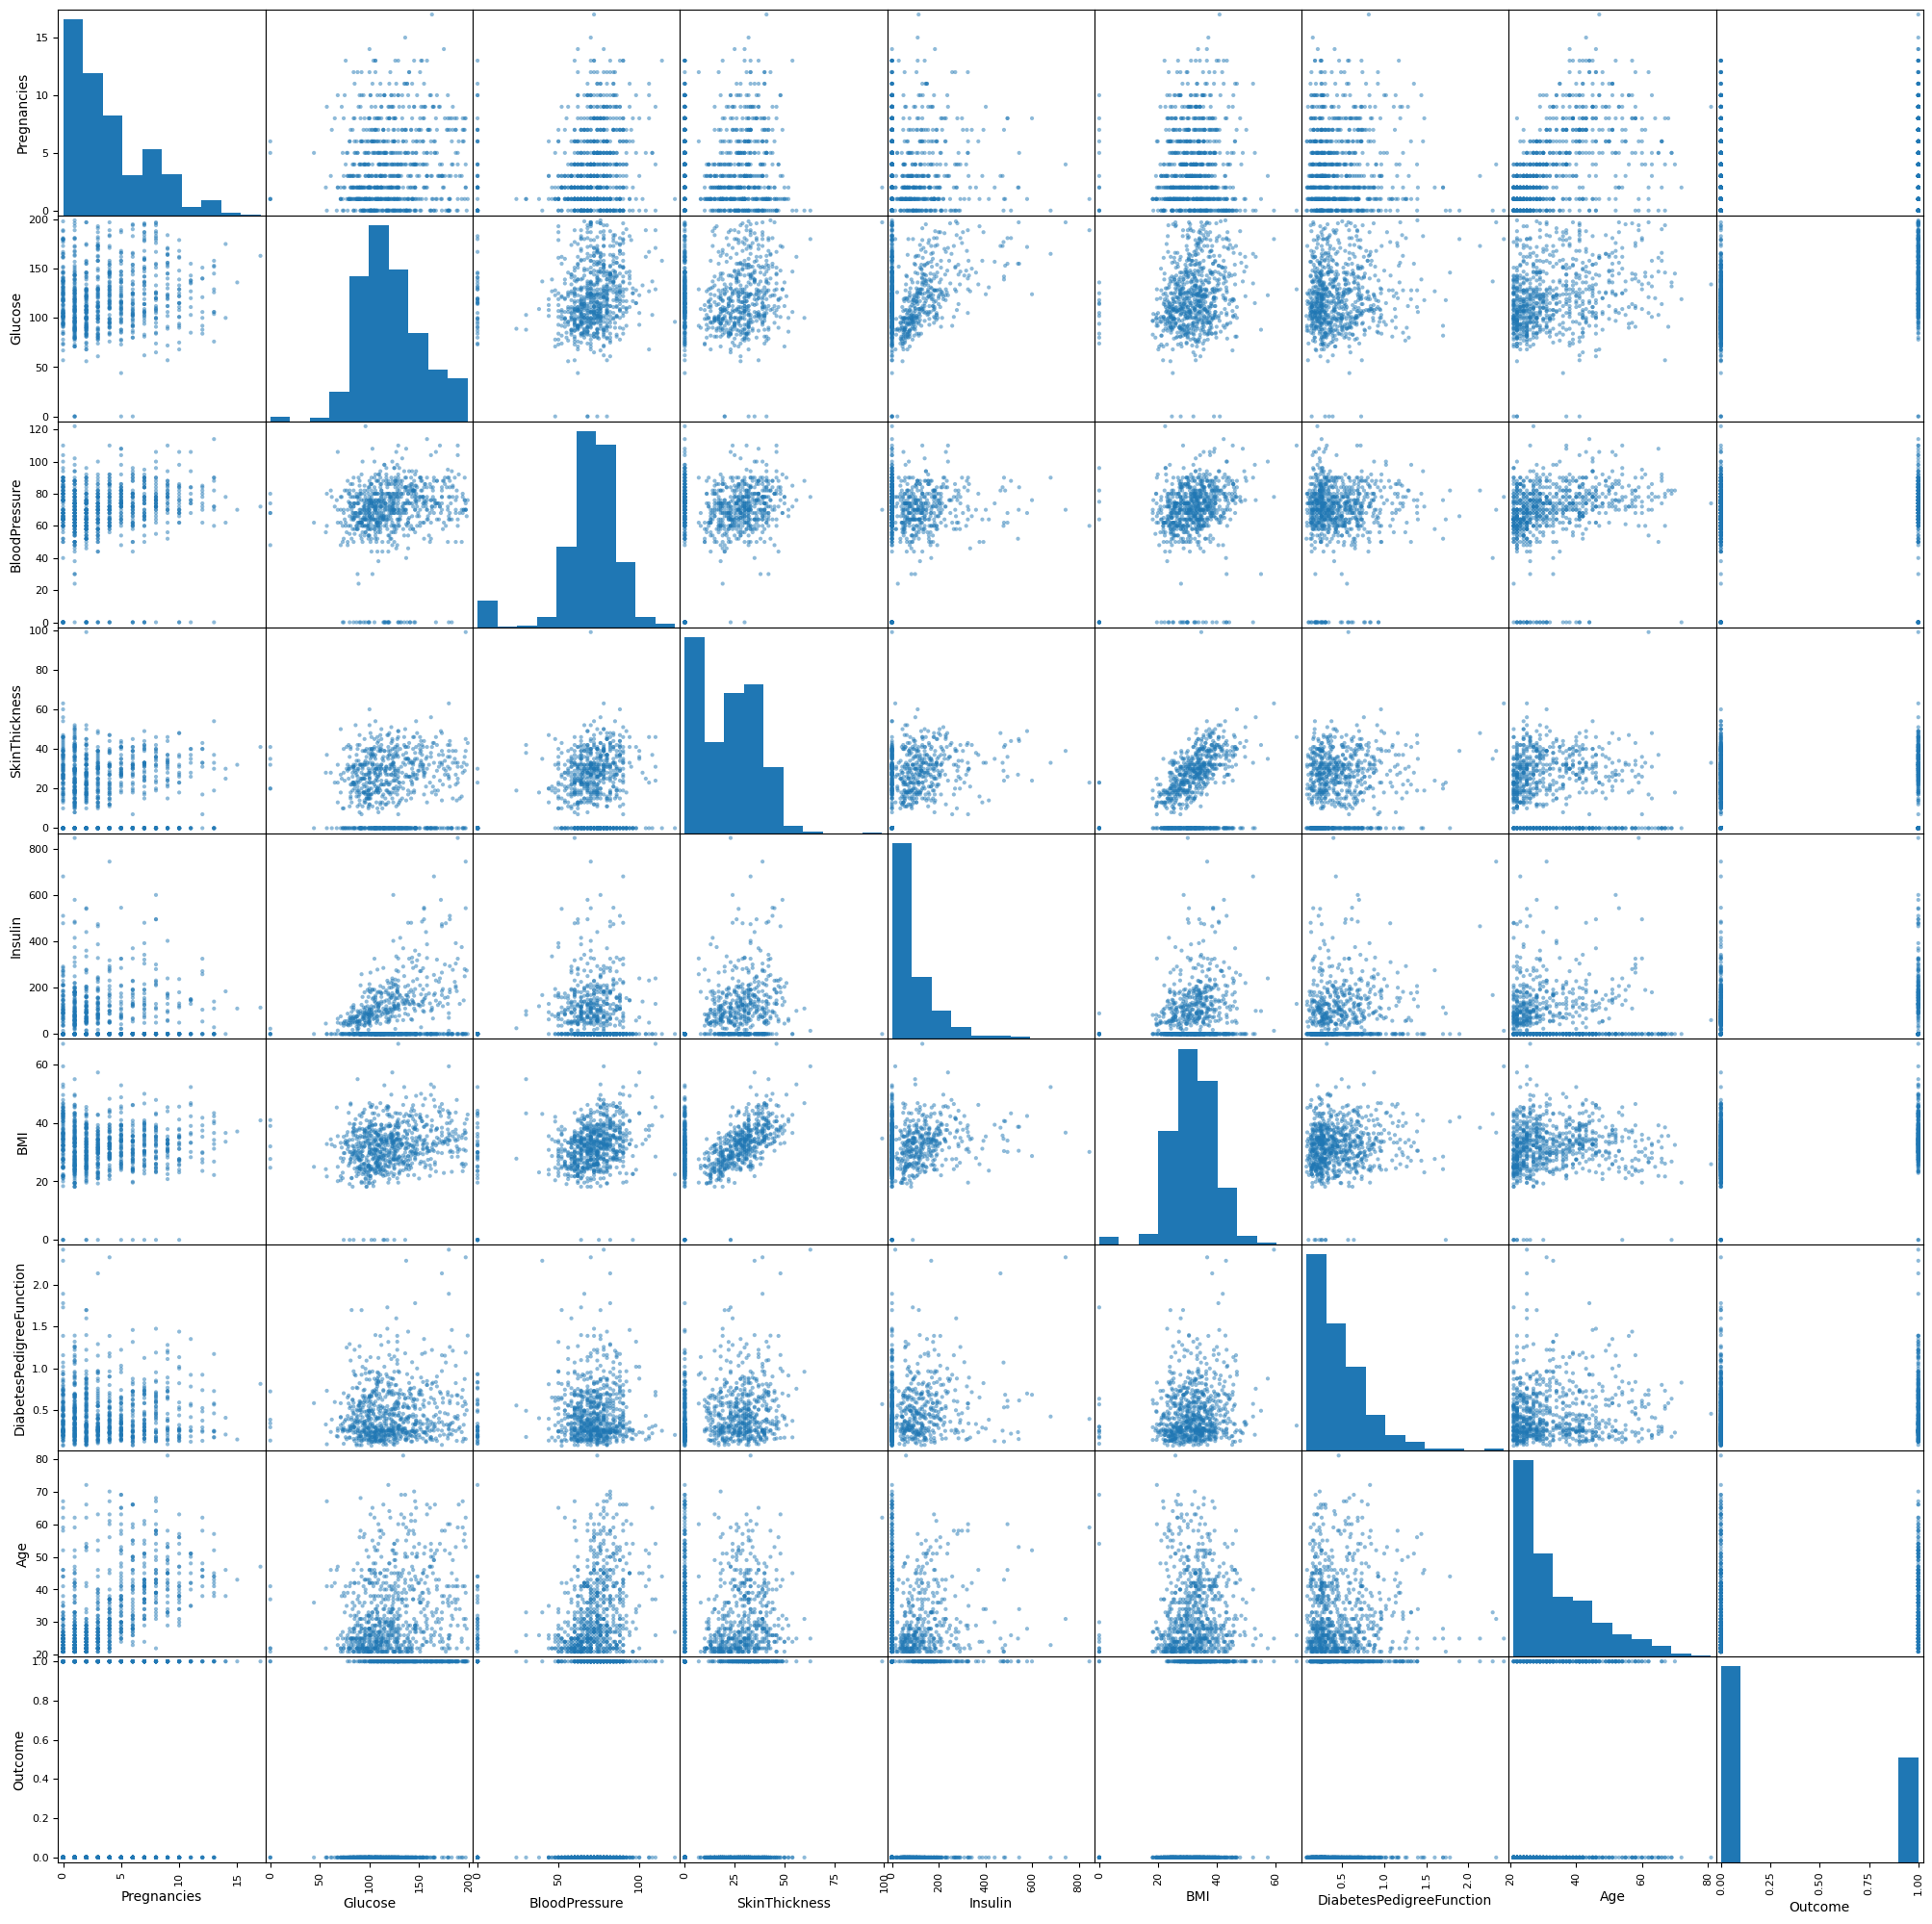

In [104]:
from pandas.plotting import scatter_matrix
scatter_matrix(df, figsize=(25, 25))

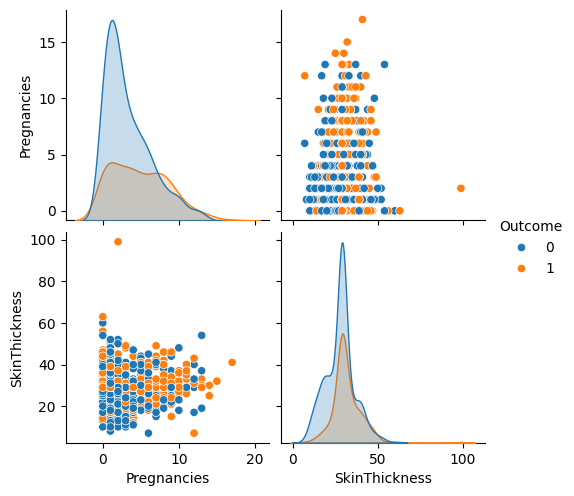

In [105]:
p = sns.pairplot(df1, hue='Outcome')

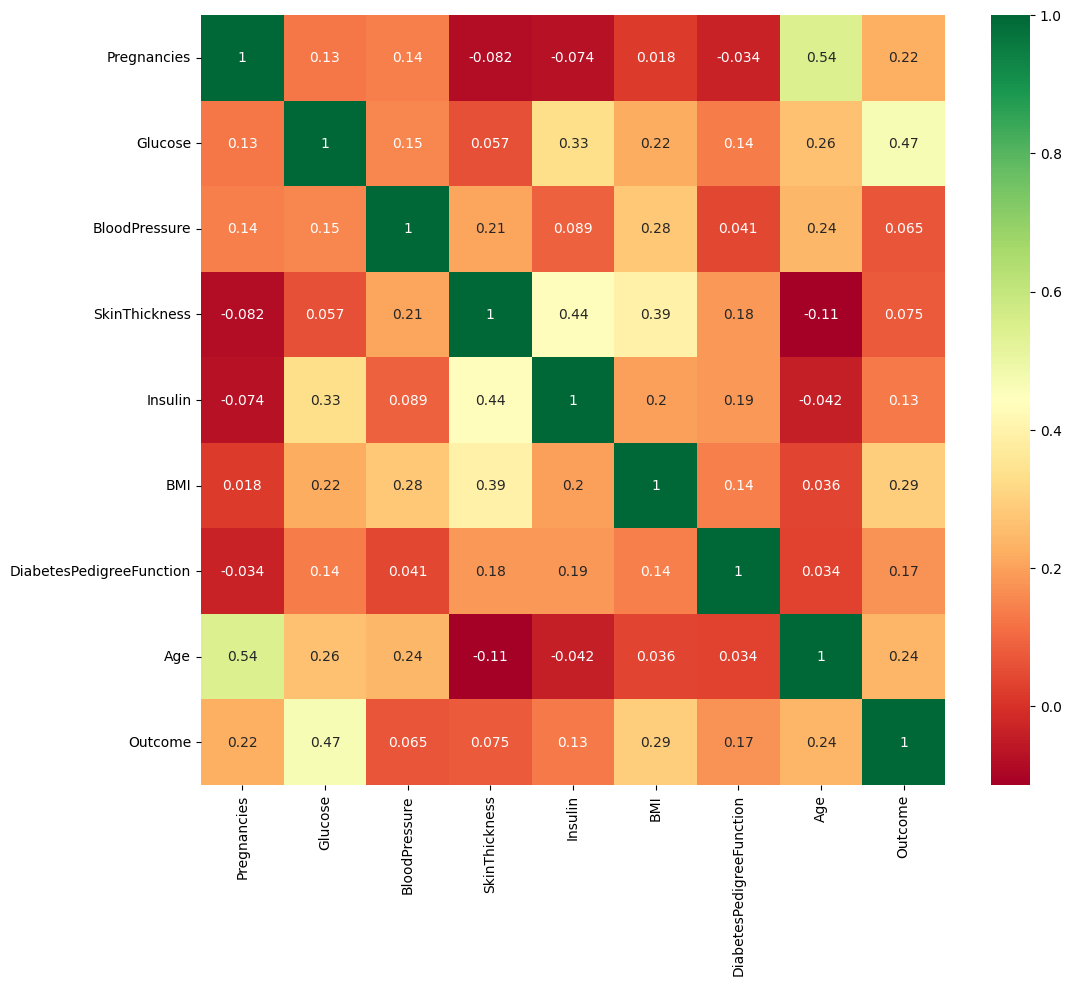

In [106]:
plt.figure(figsize=(12, 10))
p = sns.heatmap(df.corr(), annot=True, cmap='RdYlGn')

In [107]:
df1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,Diabetes,Normal,35.0,Normal,Obese,Medium,Middle,1
1,1,Normal,Normal,29.0,Normal,Overweight,Medium,Young,0
2,8,Diabetes,Normal,29.0,Normal,Normal,Medium,Young,1
3,1,Normal,Normal,23.0,Normal,Overweight,Low,Very-Young,0
4,0,Diabetes,Very-Low,35.0,High,Obese,High,Young,1
...,...,...,...,...,...,...,...,...,...
763,10,Pre-diabetes,Normal,48.0,High,Obese,Low,Senior,0
764,2,Pre-diabetes,Normal,27.0,Normal,Obese,Medium,Young,0
765,5,Pre-diabetes,Normal,23.0,Normal,Overweight,Low,Young,0
766,1,Diabetes,Low,29.0,Normal,Obese,Medium,Middle,1


In [ ]:
cat_cols = ['Glucose', 'BloodPressure', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age']

df1 = pd.get_dummies(df1, columns=cat_cols)
df1

,Pregnancies,SkinThickness,Outcome,Glucose_Low-glucose,Glucose_Normal,Glucose_Pre-diabetes,Glucose_Diabetes,BloodPressure_Very-Low,BloodPressure_Low,BloodPressure_Normal,...,BMI_Overweight,BMI_Obese,DiabetesPedigreeFunction_Low,DiabetesPedigreeFunction_Medium,DiabetesPedigreeFunction_High,Age_Very-Young,Age_Young,Age_Middle,Age_Senior,Age_Old
0,6,35.0,1,False,False,False,True,False,False,True,...,False,True,False,True,False,False,False,True,False,False
1,1,29.0,0,False,True,False,False,False,False,True,...,True,False,False,True,False,False,True,False,False,False
2,8,29.0,1,False,False,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,1,23.0,0,False,True,False,False,False,False,True,...,True,False,True,False,False,True,False,False,False,False
4,0,35.0,1,False,False,False,True,True,False,False,...,False,True,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,48.0,0,False,False,True,False,False,False,True,...,False,True,True,False,False,False,False,False,True,False
764,2,27.0,0,False,False,True,False,False,False,True,...,False,True,False,True,False,False,True,False,False,False
765,5,23.0,0,False,False,True,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
766,1,29.0,1,False,False,False,True,False,True,False,...,False,True,False,True,False,False,False,True,False,False


In [109]:
df1

,Pregnancies,SkinThickness,Outcome,Glucose_Low-glucose,Glucose_Normal,Glucose_Pre-diabetes,Glucose_Diabetes,BloodPressure_Very-Low,BloodPressure_Low,BloodPressure_Normal,...,BMI_Overweight,BMI_Obese,DiabetesPedigreeFunction_Low,DiabetesPedigreeFunction_Medium,DiabetesPedigreeFunction_High,Age_Very-Young,Age_Young,Age_Middle,Age_Senior,Age_Old
0,6,35.0,1,False,False,False,True,False,False,True,...,False,True,False,True,False,False,False,True,False,False
1,1,29.0,0,False,True,False,False,False,False,True,...,True,False,False,True,False,False,True,False,False,False
2,8,29.0,1,False,False,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,1,23.0,0,False,True,False,False,False,False,True,...,True,False,True,False,False,True,False,False,False,False
4,0,35.0,1,False,False,False,True,True,False,False,...,False,True,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,48.0,0,False,False,True,False,False,False,True,...,False,True,True,False,False,False,False,False,True,False
764,2,27.0,0,False,False,True,False,False,False,True,...,False,True,False,True,False,False,True,False,False,False
765,5,23.0,0,False,False,True,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
766,1,29.0,1,False,False,False,True,False,True,False,...,False,True,False,True,False,False,False,True,False,False


In [110]:
X = df1.drop(['Outcome'], axis=1)
y = df1['Outcome']

In [111]:
X

,Pregnancies,SkinThickness,Glucose_Low-glucose,Glucose_Normal,Glucose_Pre-diabetes,Glucose_Diabetes,BloodPressure_Very-Low,BloodPressure_Low,BloodPressure_Normal,BloodPressure_Elevated,...,BMI_Overweight,BMI_Obese,DiabetesPedigreeFunction_Low,DiabetesPedigreeFunction_Medium,DiabetesPedigreeFunction_High,Age_Very-Young,Age_Young,Age_Middle,Age_Senior,Age_Old
0,6,35.0,False,False,False,True,False,False,True,False,...,False,True,False,True,False,False,False,True,False,False
1,1,29.0,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,True,False,False,False
2,8,29.0,False,False,False,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,1,23.0,False,True,False,False,False,False,True,False,...,True,False,True,False,False,True,False,False,False,False
4,0,35.0,False,False,False,True,True,False,False,False,...,False,True,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,48.0,False,False,True,False,False,False,True,False,...,False,True,True,False,False,False,False,False,True,False
764,2,27.0,False,False,True,False,False,False,True,False,...,False,True,False,True,False,False,True,False,False,False
765,5,23.0,False,False,True,False,False,False,True,False,...,True,False,True,False,False,False,True,False,False,False
766,1,29.0,False,False,False,True,False,True,False,False,...,False,True,False,True,False,False,False,True,False,False


<Axes: xlabel='Outcome'>

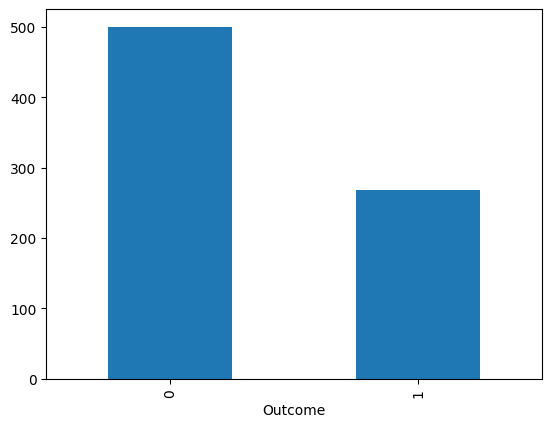

In [112]:
y.value_counts().plot(kind="bar")

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True)

In [114]:
X_train.shape

(614, 27)

In [115]:
df1.shape

(768, 28)

<Axes: xlabel='Outcome'>

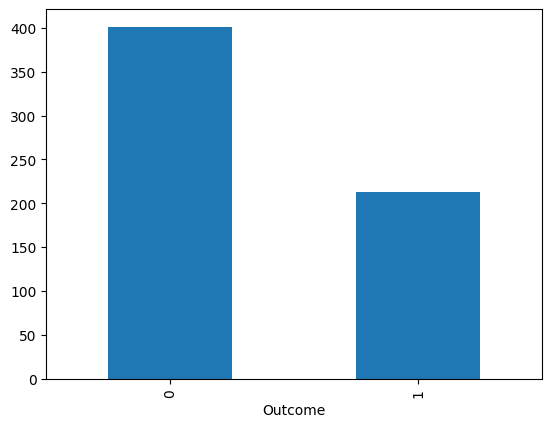

In [116]:

y_train.value_counts().plot(kind="bar")

<Axes: xlabel='Outcome'>

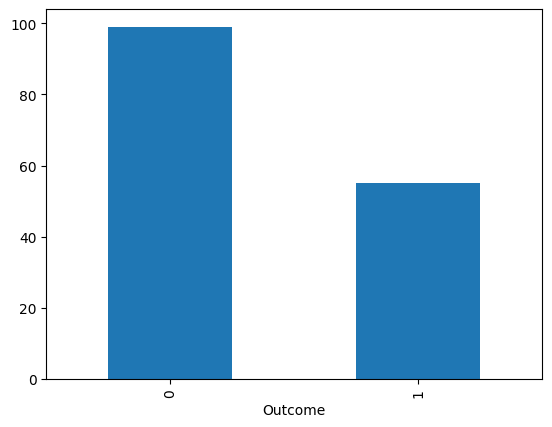

In [117]:
y_test.value_counts().plot(kind="bar")

In [118]:
from sklearn.neighbors import KNeighborsClassifier
testing_score = []
training_score = []

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

training_score.append(knn.score(X_train, y_train))
testing_score.append(knn.score(X_test, y_test))

In [119]:
testing_score

[0.5584415584415584]

In [120]:
training_score

[0.7817589576547231]

In [121]:
max_training_score = max(training_score)
train_scores_ind = [i for i, v in enumerate(
    training_score) if v == max_training_score]
print("Max training score {} % and k = {} ".format(
    max_training_score*100, list(map(lambda x: x+1, train_scores_ind))))

Max training score 78.17589576547232 % and k = [1] 


In [122]:
max_testing_score = max(testing_score)
test_scores_ind = [i for i, v in enumerate(
    testing_score) if v == max_testing_score]
print('Max testing score {} % and k = {}'.format(
    max_testing_score*100, list(map(lambda x: x+1, test_scores_ind))))

Max testing score 55.84415584415584 % and k = [1]


In [123]:
knn = KNeighborsClassifier(11)
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.6233766233766234

In [124]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model = model.fit(X_train, y_train)
predict = model.predict(X_test)  # inputs    #output
print(predict)

[0 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 1 0 1 0 1 1 1 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0
 0 1 0 0 1 0]


In [125]:
score = model.score(X_test, y_test)
print(score)

0.7272727272727273


In [126]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predict)
print(cm)

[[77 22]
 [20 35]]


In [127]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test, predict, average='macro')

(0.7039247603544945, 0.7070707070707071, 0.7053571428571428, None)

In [128]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy: ", clf.score(X_test, y_test))

Accuracy:  0.6753246753246753


In [129]:
from sklearn import svm

clf = svm.SVC(kernel='linear', C=1, gamma='auto')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.7402597402597403


In [130]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [131]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy:  0.6948051948051948
 [[76 23]
 [24 31]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.76        99
           1       0.57      0.56      0.57        55

    accuracy                           0.69       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.69      0.69      0.69       154



In [140]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,              # number of combinations to try
    cv=5,                   # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [141]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
# Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}

Accuracy:  0.7532467532467533
 [[81 18]
 [20 35]]
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

